In [ ]:
from sklearn.datasets import load_digits
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
# 1. DATA — split BEFORE touching it (honest evaluation, Day 14)
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
base.fit(X_train, y_train)
print(f"Logistic baseline test accuracy : {base.score(X_test, y_test):.3f}")
net = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(80,),early_stopping=True ,max_iter=1000, random_state=42),
)
net.fit(X_train, y_train)
print(f"Neural network  test accuracy   : {net.score(X_test, y_test):.3f}")
print(f"  (train {net.score(X_train, y_train):.3f} vs test {net.score(X_test, y_test):.3f})")
from sklearn.metrics import confusion_matrix
#train_score = base.predict(X_train , y_train)
#test_score = base.predict(X_test , y_test)
pred = base.predict(X_test)
cm = confusion_matrix(y_test, pred)
print(cm)
print(np.sum(np.bincount(y_test)))
print(np.bincount(y_test))
for size in [(16,), (64,), (128,), (64, 64)]:
    net = make_pipeline(StandardScaler(),
                        MLPClassifier(hidden_layer_sizes=size, max_iter=1000, random_state=42))
    print(size, cross_val_score(net, X, y, cv=5).mean())

In [1]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np


digits = load_digits()
X, y = digits.data, digits.target

print(X.shape[0])          # 1797 images
print(X.shape[1])          # 64 pixels each (8x8)
print(list(range(10)))     # classes 0..9

# draw one image as text (bright pixels = #)
for row in digits.images[2]:
    print("".join("#" if v > 6 else " " for v in row))

1797
64
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    ##  
   ###  
  ####  
    ##  
  ###   
 ###    
  ####  
    ### 


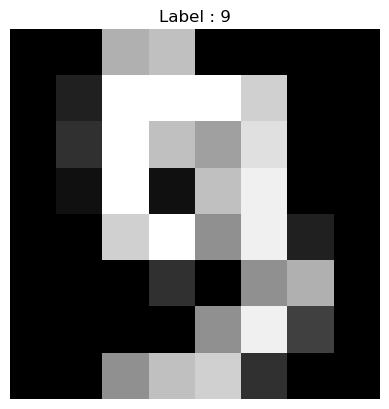

In [6]:
index = 9
plt.Figure(figsize=(6,6)) #width height in inches
plt.imshow(digits.images[index] , cmap = "gray")
plt.axis("off")
plt.title("Label : 9")
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_27208\844759784.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


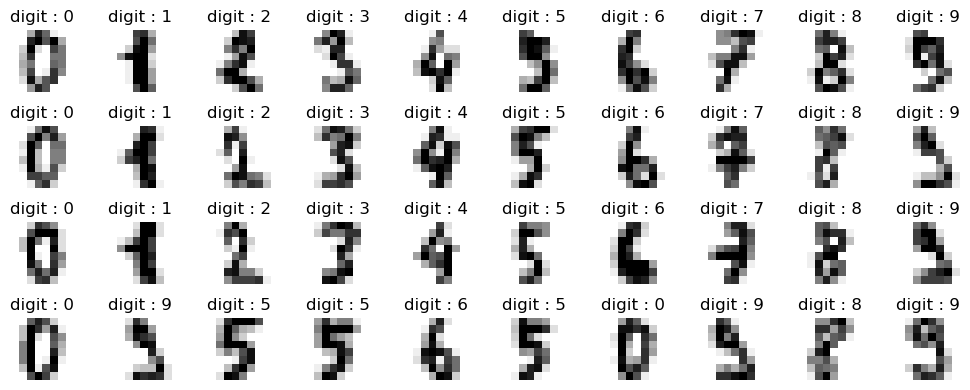

In [14]:
digits = load_digits()
fig , axes = plt.subplots(4 , 10 , figsize = (10,4))

for ax , image , label in zip(axes.ravel() , digits.images[:]  , digits.target[:]):
    ax.imshow(image , cmap = "gray_r")
    ax.set_title(f"digit : {label}")
    ax.axis("off")
fig.tight_layout()
fig.show()

In [28]:
X , y = load_digits(return_X_y= True)

X_tr , X_te , y_tr , y_te = train_test_split(X , y , test_size= 0.25  , random_state=42 , stratify=y)

base = make_pipeline(StandardScaler() , LogisticRegression(max_iter=5000))

net = make_pipeline(StandardScaler()  , MLPClassifier(hidden_layer_sizes=(80,) , early_stopping=True , random_state=0 , max_iter=1000))

base.fit(X_tr , y_tr)
net.fit(X_tr , y_tr)

base_pred = base.predict(X_te)
net_pred = net.predict(X_te)

print(f"logistic Accuracy : {round(base.score(X_te , y_te),3)}")
print(f"Neural network Accuracy : {net.score(X_te , y_te)}")

from sklearn.metrics import confusion_matrix

cm1  = confusion_matrix(y_te , base_pred)
cm2  = confusion_matrix(y_te , net_pred)
print(cm1)
print(cm2)


logistic Accuracy : 0.978
Neural network Accuracy : 0.9377777777777778
[[45  0  0  0  0  0  0  0  0  0]
 [ 0 43  0  0  1  0  0  0  2  0]
 [ 0  0 44  0  0  0  0  0  0  0]
 [ 0  0  0 46  0  0  0  0  0  0]
 [ 0  0  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 45  0  0  0  1]
 [ 0  0  0  0  0  0 44  0  1  0]
 [ 0  0  0  0  0  0  0 45  0  0]
 [ 0  3  0  0  0  0  0  0 40  0]
 [ 0  0  0  0  0  0  0  1  1 43]]
[[43  0  0  0  2  0  0  0  0  0]
 [ 0 43  1  0  0  0  0  0  0  2]
 [ 0  2 42  0  0  0  0  0  0  0]
 [ 0  0  1 45  0  0  0  0  0  0]
 [ 0  0  0  0 44  0  0  1  0  0]
 [ 0  0  0  0  0 42  0  0  0  4]
 [ 0  1  0  0  1  0 43  0  0  0]
 [ 0  0  0  0  0  0  0 45  0  0]
 [ 0  6  1  1  0  2  0  1 32  0]
 [ 0  0  0  0  0  0  0  1  1 43]]


In [29]:
for i in np.arange(10):
    print(f"{i} count is {len(y_te[y_te==i])}")

for size in [(16,), (64,), (128,), (64, 64)]:
    net = make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=size, max_iter=1000, random_state=42))
    
    print(size, cross_val_score(net, X, y, cv=5).mean())

0 count is 45
1 count is 46
2 count is 44
3 count is 46
4 count is 45
5 count is 46
6 count is 45
7 count is 45
8 count is 43
9 count is 45
(16,) 0.9232048901268957
(64,) 0.9359996904982978
(128,) 0.9293268337975858
(64, 64) 0.9343252862890745
